# Dynamic and Adaptive Attention — Practical Implementation 1

Each section below implements, from scratch or with `transformers`, a concept discussed in the slides/report:

1) Scaled Dot-Product Attention (from scratch)
2) Multi-Head Attention (from scratch)
3) Visualizing Self-Attention on a Toy Sentence
4) Rotary Positional Embeddings (RoPE)
5) KV Cache: Naive Recomputation vs. Cached Decoding (speed)
6) GQA / MQA vs. MHA: KV-Cache Memory Comparison
7) Sparse (Sliding-Window) Attention Masks
8) Attention Rollout on a Pretrained Transformer (BERT)
9) Quantization: Memory Footprint Comparison

Section 8 needs an internet connection (downloads `bert-base-uncased`).

| Section | Report concept | What the code shows |
|---|---|---|
| 1–2 | Self-Attention & Multi-Head Attention | Working from-scratch implementation matching the math |
| 3 | Attention Visualization | Heatmaps of per-head attention weights |
| 4 | RoPE (Appendix A.2) | Relative-position invariance of rotated dot products |
| 5 | KV cache, prefill vs. decode (Section 3.2/3.3) | Measured speedup from caching K/V |
| 6 | GQA/MQA (Section 3.4) | cache-size formula plotted across configs |
| 7 | Sparse Attention (Section 3.8) | Sliding-window mask + complexity reduction |
| 8 | Attention Rollout (Appendix D.2) | Real BERT rollout attributions, coreference example |
| 9 | Quantization (Section 3.7, Appendix A.3) | Eq. (9) formula + real dynamic-quantization demo |

You can screenshot the plots/outputs directly into your report or presentation as
"Practical Implementation" evidence.

## 0) Setup

In [1]:
# Install or upgrade the Hugging Face Transformers library
!pip install -q transformers --upgrade

# Import required libraries
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Display the selected device
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 80.8 MB/s eta 0:00:00
Using device: cuda


## 1) Scaled Dot-Product Attention (from scratch)

Implements Attention Equation from the report:

$$A(Q,K,V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute scaled dot-product attention.

    Q: Queries [..., n_q, d_k]
    K: Keys [..., n_k, d_k]
    V: Values [..., n_k, d_v]

    mask: Optional mask to block specific positions.optional additive mask
    broadcastable to [..., n_q, n_k], use -inf to block
    """
    d_k = Q.size(-1)

    # Compute attention scores and scale by sqrt(d_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)   # QK^T / sqrt(d_k)

    # Apply mask if provided
    if mask is not None:
        scores = scores + mask

    # Convert scores into attention weights
    attn_weights = F.softmax(scores, dim=-1)

    # Compute weighted sum of the values
    output = torch.matmul(attn_weights, V)

    return output, attn_weights

# Quick sanity check with random tensors
n_tokens, d_k, d_v = 5, 8, 8

# Create random Query, Key, and Value tensors
Q = torch.randn(1, n_tokens, d_k)
K = torch.randn(1, n_tokens, d_k)
V = torch.randn(1, n_tokens, d_v)

# Run scaled dot-product attention
out, attn = scaled_dot_product_attention(Q, K, V)

print("Output shape:", out.shape)          # [1, n_tokens, d_v]
print("Attention weights shape:", attn.shape)   # [1, n_tokens, n_tokens]
print("Each attention row sums to 1:", torch.allclose(attn.sum(-1), torch.ones(1, n_tokens), atol=1e-5))

Output shape: torch.Size([1, 5, 8])
Attention weights shape: torch.Size([1, 5, 5])
Each attention row sums to 1: True


## 2. Multi-Head Attention (from scratch)

Implements Multi-Head Attention (MHA): splits `d_model` across `h` heads, runs attention per head, concatenates, and projects with $W^O$.

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        # Ensure the model dimension can be evenly split across heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear layers for Queries, Keys, Values, and output
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        """
        Split the last dimension of x into (num_heads, d_k)
        """
        # x: [batch, seq_len, d_model] -> [batch, num_heads, seq_len, d_k]
        # Reshape into multiple attention heads
        # [batch, seq_len, d_model] -> [batch, num_heads, seq_len, d_k]
        batch, seq_len, d_model = x.shape
        x = x.view(batch, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):

        # Project the input into Queries, Keys, and Values
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # Apply scaled dot-product attention
        out, attn_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

        # Combine the attention heads back together
        batch, num_heads, seq_len, d_k = out.shape
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, num_heads * d_k)

        # Apply the final output projection
        return self.W_o(out), attn_weights

# Test the Multi-Head Attention module
d_model, num_heads, seq_len, batch = 64, 8, 6, 2
mha = MultiHeadAttention(d_model, num_heads)

# Create random input tensor
x = torch.randn(batch, seq_len, d_model)

# Run multi-head attention
out, attn_weights = mha(x)

print("MHA output shape:", out.shape)              # [batch, seq_len, d_model]
print("MHA attention weights shape:", attn_weights.shape)  # [batch, num_heads, seq_len, seq_len]

MHA output shape: torch.Size([2, 6, 64])
MHA attention weights shape: torch.Size([2, 8, 6, 6])


## 3. Visualizing Self-Attention on a Toy Sentence

In the below example, I embed a short sentence, run it through a single MHA layer, and plot the attention
matrix for a couple of heads — the same kind of visualization shown in the slides
(e.g. the "it" coreference example).

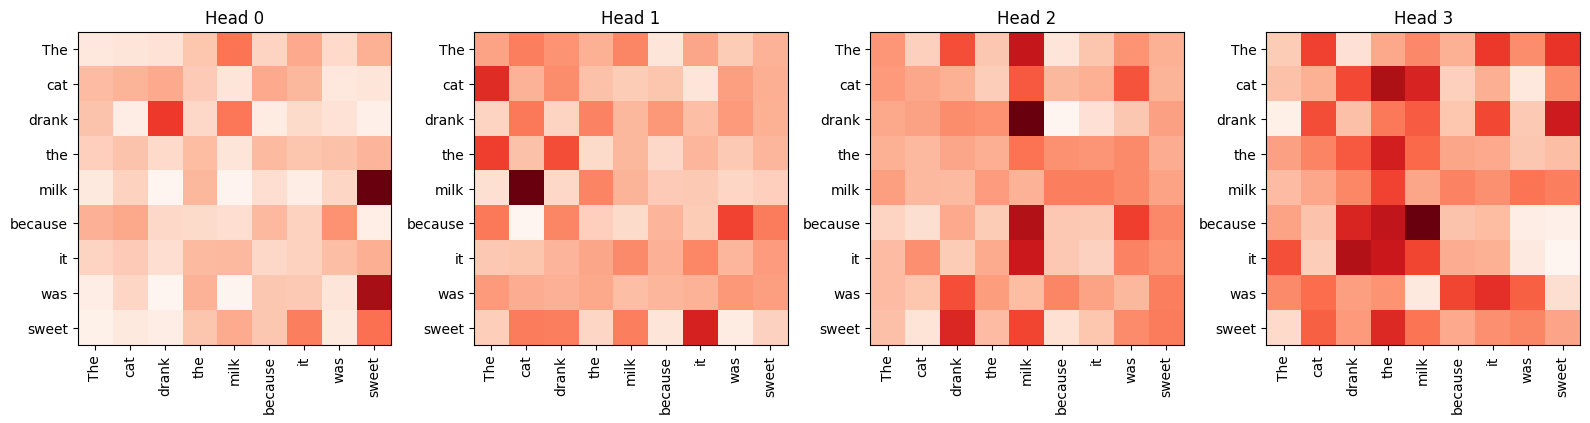

Note: weights are from an UNTRAINED layer, so patterns are random —
this cell demonstrates the mechanism/visualization, not learned linguistic behavior.


In [4]:
# Define the input tokens and number of tokens
tokens = ["The", "cat", "drank", "the", "milk", "because", "it", "was", "sweet"]
n = len(tokens)

# Set the model dimension and number of attention heads
d_model, num_heads = 32, 4

# Set random seed for reproducibility
torch.manual_seed(42)

# Create random embeddings as a stand-in for real token embeddings
embeddings = torch.randn(1, n, d_model)  # toy random embeddings (stand-in for real token embeddings)

# Create the Multi-Head Attention layer
mha_demo = MultiHeadAttention(d_model, num_heads)

# Compute attention weights
_, attn_weights = mha_demo(embeddings)   # [1, num_heads, n, n]

# Create one heatmap for each attention head
fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 4))
for h in range(num_heads):
    ax = axes[h]

    # Get attention weights for the current head
    weights = attn_weights[0, h].detach().numpy()

    # Display attention weights as a heatmap
    im = ax.imshow(weights, cmap="Reds")

    # Label the x-axis with the tokens
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=90)

    # Label the y-axis with the tokens
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens)

    # Add a title for the current attention head
    ax.set_title(f"Head {h}")

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

print("Note: weights are from an UNTRAINED layer, so patterns are random —")
print("this cell demonstrates the mechanism/visualization, not learned linguistic behavior.")

## 4. Rotary Positional Embeddings (RoPE)

Implements RoPE equation from the report: rotates query/key vectors by an angle depending on
token position, so that the dot product between rotated vectors depends only on their
*relative* position — not their absolute positions.

In [5]:
def rope_frequencies(dim, base=10000):
    # one frequency per pair of dimensions
    return 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))

def apply_rope(x, positions):
    """
    Apply Rotary Positional Embeddings (RoPE) to the input vectors.

    x: [seq_len, dim]  (dim must be even)
    positions: [seq_len] integer token positions
    """
    seq_len, dim = x.shape

    # Calculate the frequencies used for the rotations
    freqs = rope_frequencies(dim) # [dim/2]

    # Calculate rotation angles for each position
    angles = positions[:, None].float() * freqs[None, :]  # [seq_len, dim/2]

    # Separate even and odd dimensions into pairs
    x1 = x[:, 0::2]
    x2 = x[:, 1::2]

    # Calculate cosine and sine of the rotation angles
    cos, sin = angles.cos(), angles.sin()

    # Rotate each pair of dimensions
    x1_rot = x1 * cos - x2 * sin
    x2_rot = x1 * sin + x2 * cos

    # Combine the rotated dimensions
    x_rot = torch.empty_like(x)
    x_rot[:, 0::2] = x1_rot
    x_rot[:, 1::2] = x2_rot

    return x_rot

# Demonstrate the key RoPE property: dot product after rotation depends only on
# the RELATIVE distance between two positions, not their absolute positions.
dim = 16

# Set the random seed and create example query/key vectors
torch.manual_seed(0)
q_vec = torch.randn(1, dim)
k_vec = torch.randn(1, dim)

# Define a fixed relative distance between positions
relative_distance = 3

# Test different position pairs with the same relative distance
pairs_to_test = [(0, 3), (5, 8), (10, 13), (50, 53)]  # all have the same relative distance

print(f"Testing pairs with fixed relative distance = {relative_distance}\n")
for pos_q, pos_k in pairs_to_test:

    # Apply RoPE using the selected positions
    q_rot = apply_rope(q_vec, torch.tensor([pos_q]))
    k_rot = apply_rope(k_vec, torch.tensor([pos_k]))

    # Calculate the dot product between the rotated vectors
    score = (q_rot @ k_rot.T).item()
    print(f"positions ({pos_q:3d}, {pos_k:3d})  ->  rotated dot product = {score:.4f}")

print("\nAll scores are (nearly) identical: RoPE encodes RELATIVE position in the attention score.")

Testing pairs with fixed relative distance = 3

positions (  0,   3)  ->  rotated dot product = -3.1606
positions (  5,   8)  ->  rotated dot product = -3.1606
positions ( 10,  13)  ->  rotated dot product = -3.1606
positions ( 50,  53)  ->  rotated dot product = -3.1606

All scores are (nearly) identical: RoPE encodes RELATIVE position in the attention score.


## 5. KV Cache: Naive Recomputation vs. Cached Decoding

I build a tiny decoder-only stack and time autoregressive generation two ways:
1. **Naive**: recompute attention over the *entire* growing sequence at every step.
2. **Cached**: reuse previously computed keys/values and only compute the new token's
   query/key/value, as described in Section 3.2 of the report.

In [6]:
class TinyCausalSelfAttention(nn.Module):
    """Single-head causal self-attention with an explicit, growable KV cache."""
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

        # Linear projections for queries, keys, and values
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

    def forward_naive(self, x):
        # x: [1, seq_len, d_model] -- recomputes everything from scratch
        # Compute Q, K, and V for the entire sequence
        Q, K, V = self.W_q(x), self.W_k(x), self.W_v(x)

        # Create a causal mask so tokens cannot attend to future tokens
        seq_len = x.size(1)
        causal_mask = torch.triu(torch.full((seq_len, seq_len), float("-inf")), diagonal=1)

        # Compute causal self-attention
        out, _ = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

        # Only return the output for the newest token
        return out[:, -1:, :]   # only the new token's output is needed

    def forward_cached(self, x_new, cache):
        # x_new: [1, 1, d_model] -- only the newest token
        # Compute Q, K, and V only for the new token
        q_new = self.W_q(x_new)
        k_new = self.W_k(x_new)
        v_new = self.W_v(x_new)

        # Add the new key and value to the existing cache
        if cache["K"] is None:
            cache["K"], cache["V"] = k_new, v_new
        else:
            cache["K"] = torch.cat([cache["K"], k_new], dim=1)
            cache["V"] = torch.cat([cache["V"], v_new], dim=1)

        # Attend to all cached keys and values
        # No causal mask is needed because the query is only the newest token
        out, _ = scaled_dot_product_attention(q_new, cache["K"], cache["V"])  # no mask needed: only 1 query, all past keys are valid
        return out, cache

# Set model size and number of decoding steps
d_model = 128
n_steps = 400   # number of autoregressive decoding steps to simulate

# Create the attention layer and initial token
layer = TinyCausalSelfAttention(d_model)
tokens_so_far = torch.randn(1, 1, d_model)

# --- Naive: recompute full attention over the whole sequence at every step ---
start = time.time()
seq = tokens_so_far.clone()
for step in range(n_steps):

    # Recalculate attention using the entire sequence
    _ = layer.forward_naive(seq)

    # Simulate generating a new token
    new_token = torch.randn(1, 1, d_model)
    seq = torch.cat([seq, new_token], dim=1)
naive_time = time.time() - start

# --- Cached: reuse K/V from previous steps ---
# --- Cached decoding: reuse previously computed K/V values ---
start = time.time()
cache = {"K": None, "V": None}
cur = tokens_so_far.clone()
for step in range(n_steps):

     # Process only the newest token using the KV cache
    _, cache = layer.forward_cached(cur, cache)

    # Simulate generating the next token
    cur = torch.randn(1, 1, d_model)
cached_time = time.time() - start

# Compare the execution times
print(f"Naive recomputation over {n_steps} steps: {naive_time:.3f} s")
print(f"KV-cached decoding over {n_steps} steps:   {cached_time:.3f} s")
print(f"Speedup: {naive_time / cached_time:.1f}x")

Naive recomputation over 400 steps: 0.512 s
KV-cached decoding over 400 steps:   0.092 s
Speedup: 5.6x


## 6. GQA / MQA vs. MHA: KV-Cache Memory Comparison

Implements the below equation from the report:

$$\text{Cache size} = 2 \cdot n \cdot d_h \cdot n_h \cdot l \cdot (\text{bytes per number})$$

For GQA/MQA, the *effective* number of KV heads (`n_kv_heads`) shrinks, which shrinks the cache proportionally.

 Context length | MHA (n_kv_heads = 128) |  GQA (n_kv_heads = 16) |   GQA (n_kv_heads = 8) |   MQA (n_kv_heads = 1)
          1,000 |                 3.7 GB |                 0.5 GB |                 0.2 GB |                 0.0 GB
         10,000 |                37.2 GB |                 4.7 GB |                 2.3 GB |                 0.3 GB
         50,000 |               186.2 GB |                23.3 GB |                11.6 GB |                 1.5 GB
        100,000 |               372.3 GB |                46.5 GB |                23.3 GB |                 2.9 GB


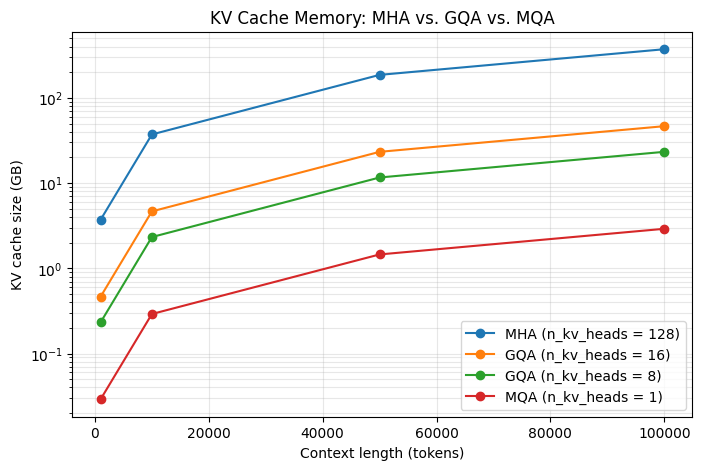

In [7]:
# Calculate the KV cache memory required for a given model configuration
def kv_cache_size_gb(n_tokens, d_head, n_kv_heads, n_layers, bytes_per_number=2):

    # Multiply by 2 because both keys and values are stored
    total_bytes = 2 * n_tokens * d_head * n_kv_heads * n_layers * bytes_per_number
    return total_bytes / (1024 ** 3)

# Roughly DeepSeek R1/V3-scale config from the report: d_head=128, n_heads=128, n_layers=61
# Define a model configuration similar in scale to DeepSeek R1/V3
d_head, n_query_heads, n_layers = 128, 128, 61
context_lengths = [1_000, 10_000, 50_000, 100_000]

# Compare different attention configurations
configs = {
    "MHA (n_kv_heads = 128)": 128,
    "GQA (n_kv_heads = 16)":  16,
    "GQA (n_kv_heads = 8)":   8,
    "MQA (n_kv_heads = 1)":   1,
}

print(f"{'Context length':>15} | " + " | ".join(f"{name:>22}" for name in configs))
for n in context_lengths:

    # Calculate cache size for each attention configuration
    row = [f"{kv_cache_size_gb(n, d_head, kv_heads, n_layers):>19.1f} GB" for kv_heads in configs.values()]
    print(f"{n:>15,} | " + " | ".join(row))

# Plot KV cache size as context length increases
plt.figure(figsize=(8, 5))
for name, kv_heads in configs.items():

    # Calculate cache sizes for the different context lengths
    sizes = [kv_cache_size_gb(n, d_head, kv_heads, n_layers) for n in context_lengths]
    plt.plot(context_lengths, sizes, marker="o", label=name)

# Add plot labels and formatting
plt.xlabel("Context length (tokens)")
plt.ylabel("KV cache size (GB)")
plt.title("KV Cache Memory: MHA vs. GQA vs. MQA")

# Use a logarithmic scale to make the differences easier to see
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 7. Sparse (Sliding-Window) Attention Mask

Implements the local-attention pattern from Section 3.8 / Fig. 4: each token only attends
to `w` neighbors on either side, giving $O(n \times w)$ cost instead of $O(n^2)$.

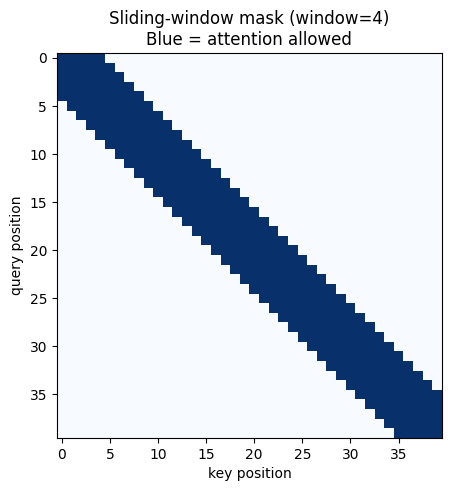

Full attention pairwise interactions: 1600
Sliding-window pairwise interactions: 360
Reduction factor: 4.4x

Output shape with sliding-window mask applied: torch.Size([1, 40, 16])
Row 20 attends only to positions: [16, 17, 18, 19, 20, 21, 22, 23, 24]


In [8]:
def sliding_window_mask(seq_len, window):
    """Returns an additive mask: 0 where attention is allowed, -inf elsewhere."""

    # Create token position indices
    idx = torch.arange(seq_len)

    # Calculate the distance between every pair of positions
    distance = (idx[:, None] - idx[None, :]).abs()

    # Allow attention only within the specified window
    allowed = distance <= window

    # Start with all positions allowed
    mask = torch.zeros(seq_len, seq_len)

    # Block positions outside the window
    mask[~allowed] = float("-inf")
    return mask

# Define sequence length and attention window
seq_len, window = 40, 4

# Create the sliding-window attention mask
mask = sliding_window_mask(seq_len, window)

# Visualize the attention mask
plt.figure(figsize=(5, 5))
plt.imshow((mask == 0).float(), cmap="Blues")
plt.title(f"Sliding-window mask (window={window})\nBlue = attention allowed")
plt.xlabel("key position"); plt.ylabel("query position")
plt.show()

# Compare the number of attention interactions
full_attn_cost = seq_len ** 2
sparse_attn_cost = seq_len * (2 * window + 1)
print(f"Full attention pairwise interactions: {full_attn_cost}")
print(f"Sliding-window pairwise interactions: {sparse_attn_cost}")
print(f"Reduction factor: {full_attn_cost / sparse_attn_cost:.1f}x")

# Test the mask with the scaled dot-product attention function
Q = K = V = torch.randn(1, seq_len, 16)

# Apply sliding-window attention
out, attn = scaled_dot_product_attention(Q, K, V, mask=mask)
print("\nOutput shape with sliding-window mask applied:", out.shape)

# Check which positions token 20 attends to
print("Row 20 attends only to positions:", torch.nonzero(attn[0, 20] > 1e-6).flatten().tolist())

## 8. Attention Rollout on a Pretrained Transformer (BERT)

Implements the method from Appendix D.2 / Abnar & Zuidema (2020): recursively multiplies
per-layer attention matrices (averaged over heads, with a residual-connection identity
term added) to get a cumulative attribution from the `[CLS]` token back to the input
tokens. Requires internet access to download `bert-base-uncased`.

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded bert-base-uncased: 12 layers, sequence length 16


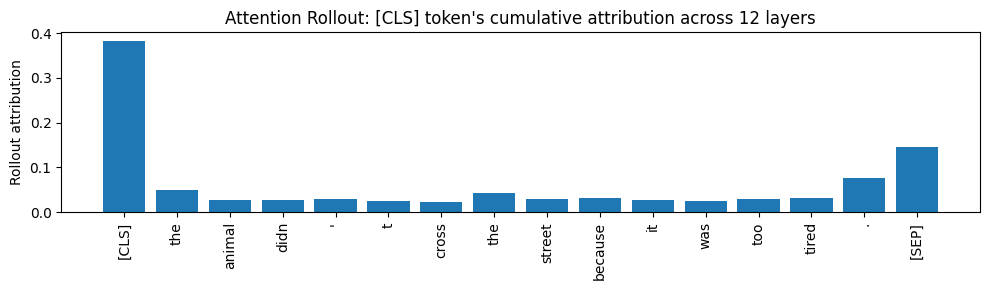


Top-5 tokens by rollout attribution:
         [CLS]  ->  0.3825
           the  ->  0.0486
           the  ->  0.0428
             .  ->  0.0761
         [SEP]  ->  0.1461


In [9]:
# Import the BERT tokenizer and model
from transformers import AutoTokenizer, AutoModel

# Load a pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name, output_attentions=True)

# Set the model to evaluation mode
bert.eval()

# Define the input sentence
sentence = "The animal didn't cross the street because it was too tired."

# Tokenize the sentence
inputs = tokenizer(sentence, return_tensors="pt")

# Get token IDs and convert them back to token strings
tokens_ids = inputs["input_ids"][0]
tokens_str = tokenizer.convert_ids_to_tokens(tokens_ids)

# Run BERT without calculating gradients
with torch.no_grad():
    outputs = bert(**inputs)

# outputs.attentions: tuple of length n_layers, each [batch, n_heads, seq_len, seq_len]
# Extract attention weights from all layers
attentions = outputs.attentions

# Get the number of layers and sequence length
n_layers = len(attentions)
seq_len = attentions[0].shape[-1]
print(f"Loaded {model_name}: {n_layers} layers, sequence length {seq_len}")

def attention_rollout(attentions):
    """
    Combine attention across layers to estimate cumulative token attribution.
    attentions: list of [batch, n_heads, seq_len, seq_len] tensors (one per layer)
    Returns: [seq_len, seq_len] cumulative rollout matrix
    """
    # Average over heads, then add identity to account for the residual connection,
    # and renormalize so each row sums to 1 again.
    # Start with the identity matrix to represent the initial token information
    result = torch.eye(seq_len)

    for layer_attn in attentions:

        # Average attention weights across all attention heads
        avg_heads = layer_attn[0].mean(dim=0)             # [seq_len, seq_len]

        # Add the residual connection
        avg_heads = avg_heads + torch.eye(seq_len)          # residual term

        # Normalize rows so they sum to 1
        avg_heads = avg_heads / avg_heads.sum(dim=-1, keepdim=True)

        # Combine this layer's attention with previous layers
        result = avg_heads @ result
    return result

# Calculate cumulative attention rollout across all BERT layers
rollout = attention_rollout(attentions)

# Get the rollout attribution from the [CLS] token
cls_rollout = rollout[0]   # attribution FROM the [CLS] token back to every input token

# Visualize the [CLS] token's cumulative attribution
plt.figure(figsize=(10, 3))
plt.bar(range(seq_len), cls_rollout.detach().numpy())
plt.xticks(range(seq_len), tokens_str, rotation=90)
plt.ylabel("Rollout attribution")
plt.title("Attention Rollout: [CLS] token's cumulative attribution across 12 layers")
plt.tight_layout()
plt.show()

# Display the tokens with the highest rollout attribution
top_k = 5
top_indices = torch.topk(cls_rollout, top_k).indices.tolist()
print(f"\nTop-{top_k} tokens by rollout attribution:")
for i in sorted(top_indices):
    print(f"  {tokens_str[i]:>12s}  ->  {cls_rollout[i].item():.4f}")

## 9. Quantization: Memory Footprint Comparison

Implements Eq. (9) from the report (`Memory = n_params x bits_per_param`), and also runs a
real `torch.quantization.quantize_dynamic` pass on a small linear model to show the
on-disk size shrinking in practice.

Memory footprint for a 70B-parameter model:

          FP32:  260.8 GB
   FP16 / BF16:  130.4 GB
          INT8:   65.2 GB
          INT4:   32.6 GB


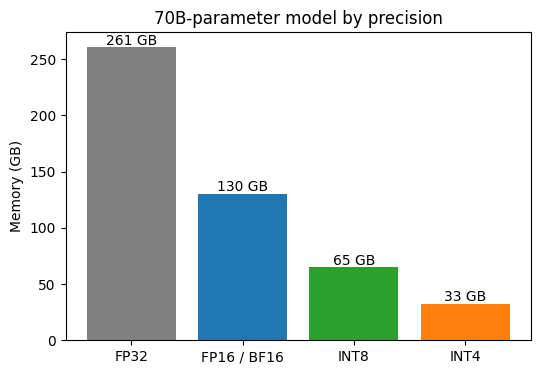


Small real-world example (TinyMLP, 3 linear layers of 1024x1024):
  FP32 state_dict size:  12303.0 KB
  INT8 state_dict size:   3088.9 KB
  Reduction: 3.98x


/tmp/ipykernel_1131/2524658427.py:54: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  int8_model = torch.quantization.quantize_dynamic(fp32_model, {nn.Linear}, dtype=torch.qint8)


In [10]:
# Calculate the approximate memory needed to store model parameters
def model_memory_gb(n_params_billion, bits_per_param):
    n_params = n_params_billion * 1e9
    total_bits = n_params * bits_per_param
    return total_bits / 8 / (1024 ** 3)

# Define different numerical precisions
precisions = {"FP32": 32, "FP16 / BF16": 16, "INT8": 8, "INT4": 4}

# Set the model size to 70 billion parameters
n_params_billion = 70   # matches the 70B example in the report

print(f"Memory footprint for a {n_params_billion}B-parameter model:\n")

# Calculate and display memory usage for each precision
sizes = []
for name, bits in precisions.items():
    gb = model_memory_gb(n_params_billion, bits)
    sizes.append(gb)
    print(f"  {name:>12s}: {gb:6.1f} GB")

# Visualize memory usage for each precision
plt.figure(figsize=(6, 4))
plt.bar(precisions.keys(), sizes, color=["gray", "tab:blue", "tab:green", "tab:orange"])
plt.ylabel("Memory (GB)")
plt.title(f"{n_params_billion}B-parameter model by precision")
for i, v in enumerate(sizes):
    plt.text(i, v + 2, f"{v:.0f} GB", ha="center")
plt.show()

# --- Real, small-scale demonstration with dynamic quantization ---
# --- demonstration using dynamic INT8 quantization ---
import os

# Define a small multi-layer perceptron
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()

        # Three fully connected layers
        self.fc1 = nn.Linear(1024, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 1024)

    def forward(self, x):

        # Pass the input through all three layers
        return self.fc3(self.fc2(self.fc1(x)))

# Create the original FP32 model
fp32_model = TinyMLP()

# Create an INT8 dynamically quantized version
int8_model = torch.quantization.quantize_dynamic(fp32_model, {nn.Linear}, dtype=torch.qint8)

# Save a model temporarily and measure its file size
def save_and_measure(model, path):
    torch.save(model.state_dict(), path)

    # Get file size in KB
    size_kb = os.path.getsize(path) / 1024

    # Remove the temporary file
    os.remove(path)

    return size_kb

# Measure the FP32 and INT8 model sizes
fp32_kb = save_and_measure(fp32_model, "fp32_tmp.pt")
int8_kb = save_and_measure(int8_model, "int8_tmp.pt")

# Compare the storage requirements
print(f"\nSmall real-world example (TinyMLP, 3 linear layers of 1024x1024):")
print(f"  FP32 state_dict size: {fp32_kb:8.1f} KB")
print(f"  INT8 state_dict size: {int8_kb:8.1f} KB")
print(f"  Reduction: {fp32_kb / int8_kb:.2f}x")